In [0]:
%pip install statsmodels geopandas

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import geopandas as gpd
import matplotlib.patheffects as pe
import numpy as np
from matplotlib.patches import FancyArrowPatch
from matplotlib import cm, colors

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
df_pop = spark.table("workspace.default.timeseries_crisis").toPandas()
df_sev = spark.table("workspace.default.inform_severity_index").toPandas()
df_fund = (
    spark.table("workspace.default.fts_incoming_funding_global")
    .select("date", "amountUSD", "srcLocations","destLocations")
    .toPandas()
)
df_iso3 = spark.table("workspace.default.countryiso3code").toPandas()


In [0]:
df_pop['month-year'] = df_pop['Date'].astype(str).str[:7]
df_pop_m=df_pop.groupby(['Crisis_Name', 'month-year'])[['Wiki_Pageviews', 'Google_Trends_Index']].mean().reset_index()
df_pop_m.head()

,Crisis_Name,month-year,Wiki_Pageviews,Google_Trends_Index
0,Afghanistan Complex Crisis,2025-01,106.935484,0.0
1,Afghanistan Complex Crisis,2025-02,124.214286,0.0
2,Afghanistan Complex Crisis,2025-03,125.419355,0.0
3,Afghanistan Complex Crisis,2025-04,109.100000,0.0
4,Afghanistan Complex Crisis,2025-05,130.709677,0.0


In [0]:
mapping = {
    "Afghanistan Complex Crisis": "Complex crisis in Afghanistan",
    "Burkina Faso Climatic & Conflict": "Conflict and Climatic Shocks in Burkina Faso",
    "CAR Complex Crisis": "Conflict and Climatic Shocks in CAR",
    "Cameroon Multiple Crises": "Multiple crises in Cameroon",
    "Colombia Conflict & Shocks": "Conflict and Climatic Shocks in Colombia",
    "DPRK Complex Crisis": "Complex crisis in DPRK",
    "DRC Complex Crisis": "Complex crisis in DRC",
    "Ethiopia Conflict & Drought": "Conflict, Climatic and Economic shocks in Ethiopia",
    "Haiti Complex Crisis": "Complex crisis in Haiti",
    "Horn of Africa Drought": "Eastern Africa Regional Drought Crisis",
    "Iran Multiple Crises": "Multiple crises in Iran",
    "Lake Chad & BAY States (Nigeria/Chad)": "Lake Chad basin regional crisis",
    "Lebanon Economic Crisis": "Complex crisis in Lebanon",
    "Mali Complex Crisis": "Complex crisis in Mali",
    "Mozambique Crises": "Multiple Crises in Mozambique",
    "Myanmar Multiple Crises (Post-Coup)": "Multiple crises in Myanmar",
    "Niger Complex Crisis": "Complex crisis in Niger",
    "Nigeria Northwest Conflict": "Conflict in North West Nigeria",
    "Pakistan Crises (Economic & Climatic)": "Multiple crises in Pakistan",
    "Palestine / Gaza / West Bank": "Multiple crises in Palestine",
    "Rohingya Regional Crisis": "Rohingya Regional Crisis",
    "Somalia Crisis": "Complex crisis in Somalia",
    "South Sudan Crisis": "Complex crisis in South Sudan",
    "Sudan Complex Crisis": "Complex crisis in Sudan",
    "Syrian Regional Crisis": "Syrian Regional Crisis",
    "Ukraine Conflict": "Conflict in Ukraine",
    "Venezuela Political & Economic": "Political and Economic crisis in Venezuela",
    "Yemen Complex Crisis": "Complex crisis in Yemen",
}

df_pop_m["crisis_name_stand"] = df_pop_m["Crisis_Name"].replace(mapping)
df_pop_m.head()

,Crisis_Name,month-year,Wiki_Pageviews,Google_Trends_Index,crisis_name_stand
0,Afghanistan Complex Crisis,2025-01,106.935484,0.0,Complex crisis in Afghanistan
1,Afghanistan Complex Crisis,2025-02,124.214286,0.0,Complex crisis in Afghanistan
2,Afghanistan Complex Crisis,2025-03,125.419355,0.0,Complex crisis in Afghanistan
3,Afghanistan Complex Crisis,2025-04,109.100000,0.0,Complex crisis in Afghanistan
4,Afghanistan Complex Crisis,2025-05,130.709677,0.0,Complex crisis in Afghanistan


In [0]:
df_sev['month-year'] = df_sev['_internal_filter_date'].astype(str).str[:7]
df_sev.head()

,crisis_id,crisis_name,connected_crises,drivers,regional_or_country,country_level,individual_aggregated,iso3,country,regions,INFORM Severity Index,INFORM Severity category (numeric),INFORM Severity category,Reliability,Impact of the crisis,Geographical Impact,Human Impact,Conditions of affected people,People in need,Concentration of conditions,Complexity,Society and safety,Operating environment,Last updated,_internal_filter_date,period,month-year
0,AFG001,Complex crisis in Afghanistan,['AFG005'],"['Conflict', 'Violence', 'Displacement', 'Drou...",Country,Yes,Individual,['AFG'],['Afghanistan'],['Asia'],8.6,5.0,Very High,Very High,9.569648,9.854819,9.403636,9.000000,10.000000,8.000000,7.133003,6.728707,7.5,2025-01-22,2025-01-01,Jan2025,2025-01
1,AGO002,Drought in South-West Angola,None,['Drought'],Country,Yes,Individual,['AGO'],['Angola'],['Africa'],5.8,3.0,Medium,High,5.370314,8.270881,2.949394,7.078597,8.157193,6.000000,4.029442,5.606839,2.0,2025-01-30,2025-01-01,Jan2025,2025-01
2,ARM003,Refugees from Nagorno-Karabakh in Armenia,['AZE002'],"['Displacement', 'Socio-political']",Country,Yes,Individual,['ARM'],['Armenia'],['Middle east'],4.3,3.0,Medium,Very High,4.656991,6.240463,3.681567,5.203699,4.407398,6.000000,2.729082,2.952071,2.5,2025-01-23,2025-01-01,Jan2025,2025-01
3,BDI001,Climatic shocks in Burundi,"['RWA002', 'TZA002']","['Violence', 'Displacement', 'Floods']",Country,Yes,Individual,['BDI'],['Burundi'],['Africa'],6.4,4.0,High,Very High,6.846136,8.057108,6.071001,6.472504,6.945009,6.000000,5.964821,5.367527,6.5,2025-01-24,2025-01-01,Jan2025,2025-01
4,BEN002,Conflict in northern region of Benin,None,"['Conflict', 'Displacement', 'Violence']",Country,Yes,Individual,['BEN'],['Benin'],['Africa'],4.3,3.0,Medium,Very High,4.544885,3.471881,5.023471,3.842673,2.569507,5.115839,4.664363,5.266656,4.0,2025-01-30,2025-01-01,Jan2025,2025-01


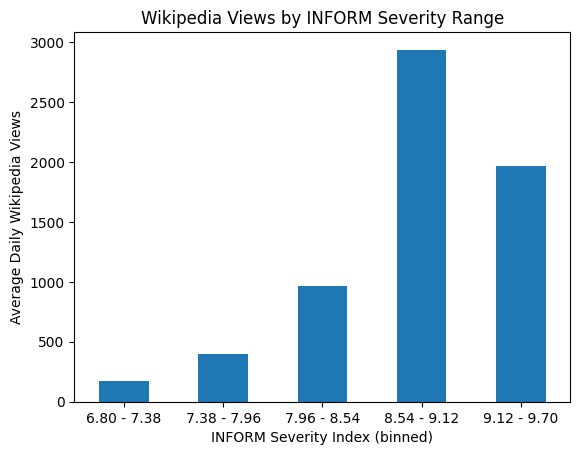

In [0]:
merged = pd.merge(df_pop_m, df_sev, left_on=['crisis_name_stand','month-year'], right_on=['crisis_name','month-year'], how='inner')

merged["severity_bin"] = pd.cut(merged["INFORM Severity Index"], bins=5)

agg = merged.groupby("severity_bin",observed=False)["Wiki_Pageviews"].mean()

formatted_index = [
    f"{interval.left:.2f} - {interval.right:.2f}"
    for interval in agg.index
]

ax = agg.plot(kind="bar")

ax.set_xticklabels(formatted_index, rotation=0)

plt.xlabel("INFORM Severity Index (binned)")
plt.ylabel("Average Daily Wikipedia Views")
plt.title("Wikipedia Views by INFORM Severity Range")

plt.show()

1330 Country Level while 957 not, but we will identify crisis money allocation based on that due to data limitations

In [0]:
merged.head()

,Crisis_Name,month-year,Wiki_Pageviews,Google_Trends_Index,crisis_name_stand,crisis_id,crisis_name,connected_crises,drivers,regional_or_country,country_level,individual_aggregated,iso3,country,regions,INFORM Severity Index,INFORM Severity category (numeric),INFORM Severity category,Reliability,Impact of the crisis,Geographical Impact,Human Impact,Conditions of affected people,People in need,Concentration of conditions,Complexity,Society and safety,Operating environment,Last updated,_internal_filter_date,period,severity_bin
0,Afghanistan Complex Crisis,2025-01,106.935484,0.0,Complex crisis in Afghanistan,AFG001,Complex crisis in Afghanistan,['AFG005'],"['Conflict', 'Violence', 'Displacement', 'Drou...",Country,Yes,Individual,['AFG'],['Afghanistan'],['Asia'],8.6,5.0,Very High,Very High,9.569648,9.854819,9.403636,9.0,10.0,8.0,7.133003,6.728707,7.5,2025-01-22,2025-01-01,Jan2025,"(8.54, 9.12]"
1,Afghanistan Complex Crisis,2025-02,124.214286,0.0,Complex crisis in Afghanistan,AFG001,Complex crisis in Afghanistan,['AFG005'],"['Conflict', 'Violence', 'Displacement', 'Drou...",Country,Yes,Individual,['AFG'],['Afghanistan'],['Asia'],8.8,5.0,Very High,High,9.566531,9.854819,9.398455,9.0,10.0,8.0,7.725578,6.721473,8.5,2025-02-25,2025-02-01,Feb2025,"(8.54, 9.12]"
2,Afghanistan Complex Crisis,2025-03,125.419355,0.0,Complex crisis in Afghanistan,AFG001,Complex crisis in Afghanistan,['AFG005'],"['Conflict', 'Violence', 'Displacement', 'Drou...",Country,Yes,Individual,['AFG'],['Afghanistan'],['Asia'],8.8,5.0,Very High,High,9.566934,9.854819,9.399125,9.0,10.0,8.0,7.726144,6.722940,8.5,2025-03-17,2025-03-01,Mar2025,"(8.54, 9.12]"
3,Afghanistan Complex Crisis,2025-04,109.100000,0.0,Complex crisis in Afghanistan,AFG001,Complex crisis in Afghanistan,['AFG005'],"['Conflict', 'Violence', 'Displacement', 'Drou...",Country,Yes,Individual,['AFG'],['Afghanistan'],['Asia'],8.8,5.0,Very High,High,9.565804,9.854819,9.397246,9.0,10.0,8.0,7.724550,6.718806,8.5,2025-04-30,2025-04-01,Apr2025,"(8.54, 9.12]"
4,Afghanistan Complex Crisis,2025-05,130.709677,0.0,Complex crisis in Afghanistan,AFG001,Complex crisis in Afghanistan,['AFG005'],"['Conflict/ Violence', 'Political/economic cri...",Country,Yes,Individual,['AFG'],['Afghanistan'],['Asia'],8.8,5.0,Very High,High,9.560890,9.854819,9.389063,9.0,10.0,8.0,7.717345,6.700096,8.5,2025-05-20,2025-05-01,May2025,"(8.54, 9.12]"


In [0]:
df_fund['month-year'] = df_fund['date'].astype(str).str[:7]
df_fund = df_fund.dropna(subset=["destLocations"])
df_fund.head()


,date,amountUSD,srcLocations,destLocations,month-year
0,2026-02-04,31335988.0,None,"ABW,ARG,BOL,BRA,CHL,COL,CRI,CUW,DOM,ECU,GUY,ME...",2026-02
1,2024-08-02,1046639.0,SWE,"ABW,ARG,BOL,BRA,CHL,COL,CRI,CUW,DOM,ECU,GUY,ME...",2024-08
2,2026-04-17,1609.0,None,AFG,2026-04
3,2026-04-17,1105651.0,None,AFG,2026-04
4,2026-04-17,36502.0,None,AFG,2026-04


ASSUMPTION: Split the donation money evenly between destination locations if there's more than one

In [0]:
# split destination codes into lists
df_fund["dest_list"] = df_fund["destLocations"].fillna("").str.split(",")

# count destinations per row
df_fund["n_dest"] = df_fund["dest_list"].apply(lambda x: len([i for i in x if i]))

# avoid division issues for empty lists
df_fund["amountUSD_split"] = df_fund["amountUSD"] / df_fund["n_dest"].where(df_fund["n_dest"] > 0)

# explode to one row per destination
df_fund = df_fund.explode("dest_list")

# clean up destination column
df_fund["destLocations"] = df_fund["dest_list"].str.strip()

# drop helper column
df_fund = df_fund.drop(columns=["dest_list"])

df_fund["amountUSD"] = df_fund["amountUSD_split"]
df_fund = df_fund.drop(columns=["amountUSD_split", "n_dest"])

df_fund_m=df_fund.groupby(['destLocations', 'month-year'])[['amountUSD']].sum().reset_index()
df_fund_m.head()


,destLocations,month-year,amountUSD
0,1514,None,0.0
1,2026,None,0.0
2,ABW,2024-08,1046639.0
3,ABW,2026-02,31335988.0
4,AFG,2022-12,1945629.0


In [0]:
merged["iso3"] = merged["iso3"].str.replace(r"[\[\]']", "", regex=True)
merged["iso3_list"] = merged["iso3"].str.split(",")
merged = merged.explode("iso3_list")
merged["iso3"] = merged["iso3_list"].str.strip()
merged = merged.drop(columns=["iso3_list"])

merged = pd.merge(merged, df_fund_m, left_on=['iso3','month-year'], right_on=['destLocations','month-year'], how='inner')
merged.head()


merged = merged[["month-year","crisis_name", "iso3", "INFORM Severity Index","amountUSD","Wiki_Pageviews"]]
merged.head()



,month-year,crisis_name,iso3,INFORM Severity Index,amountUSD,Wiki_Pageviews
0,2025-01,Complex crisis in Afghanistan,AFG,8.6,58146.0,106.935484
1,2025-03,Complex crisis in Afghanistan,AFG,8.8,6100978.0,125.419355
2,2025-05,Complex crisis in Afghanistan,AFG,8.8,6976462.0,130.709677
3,2025-06,Complex crisis in Afghanistan,AFG,9.0,-2953675.0,129.866667
4,2025-07,Complex crisis in Afghanistan,AFG,9.0,15113595.0,93.612903


In [0]:
# X = merged[["INFORM Severity Index", "Wiki_Pageviews"]]
# y = merged["amountUSD"]

# X = sm.add_constant(X)
# model = sm.OLS(y, X).fit()

# print(model.summary())
merged["month_year_dt"] = pd.to_datetime(merged["month-year"], format="%Y-%m")
merged = merged.sort_values(["crisis_name", "month_year_dt"])
merged["Wiki_Pageviews_lag1"] = merged.groupby("crisis_name")["Wiki_Pageviews"].shift(1)
df_reg = merged.dropna(subset=["Wiki_Pageviews_lag1"])

model = smf.ols(
    "amountUSD ~ Q('INFORM Severity Index') + Wiki_Pageviews_lag1 + C(Q('month-year'))",
    data=df_reg
).fit()

print(model.summary())

merged["log_views_lag1"] = np.log1p(merged["Wiki_Pageviews_lag1"])

model = smf.ols(
    "amountUSD ~ Q('INFORM Severity Index') + Q('log_views_lag1') + C(Q('month-year'))",
    data=df_reg
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              amountUSD   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     5.130
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.17e-07
Time:                        07:40:00   Log-Likelihood:                -3193.7
No. Observations:                 185   AIC:                             6415.
Df Residuals:                     171   BIC:                             6460.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

<Axes: ylabel='Count'>

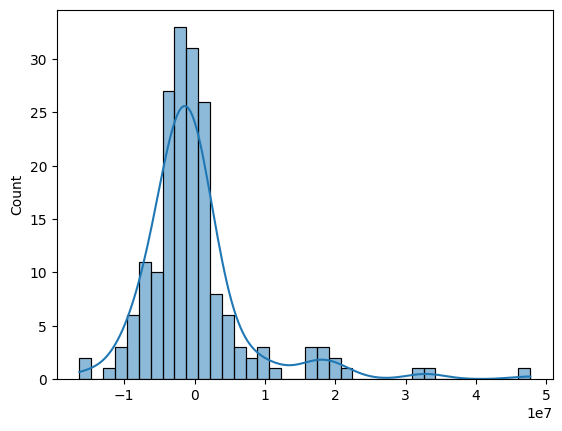

In [0]:
sns.histplot(model.resid, kde=True)

In [0]:
df_sev_copy = df_sev
df_sev_copy["iso3"] = df_sev_copy["iso3"].str.replace(r"[\[\]']", "", regex=True)
df_sev_copy["iso3_list"] = df_sev_copy["iso3"].str.split(",")
df_sev_copy = df_sev_copy.explode("iso3_list")
df_sev_copy["iso3"] = df_sev_copy["iso3_list"].str.strip()
df_sev_copy = df_sev_copy.drop(columns=["iso3_list"])
df_sev_copy=df_sev_copy.groupby(['iso3', 'month-year'])[['INFORM Severity Index']].mean().reset_index()
df_sev_copy.head()

,iso3,month-year,INFORM Severity Index
0,AFG,2025-01,8.6
1,AFG,2025-02,8.8
2,AFG,2025-03,8.8
3,AFG,2025-04,8.8
4,AFG,2025-05,8.8


In [0]:
merged_map = pd.merge(df_fund, df_sev_copy, left_on=['destLocations','month-year'], right_on=['iso3','month-year'], how='inner')

merged_map = merged_map.dropna(subset=["destLocations"])

merged_map = merged_map[
    merged_map["destLocations"].isin(df_iso3["alpha-3"]) &
    merged_map["srcLocations"].isin(df_iso3["alpha-3"])
]

merged_map = merged_map.groupby(
    ["destLocations", "srcLocations"]
).agg({
    "amountUSD": "sum",
    "INFORM Severity Index": "mean"
}).reset_index()


merged_map = merged_map[
    (merged_map["amountUSD"] != 0) &
    (merged_map["srcLocations"] != merged_map["destLocations"])
]


In [0]:
top5src = merged_map.groupby('srcLocations')[['amountUSD']].sum().reset_index().sort_values("amountUSD", ascending=False).head(5)["srcLocations"]
top5src


23    JPN
42    USA
30    NOR
9     DEU
5     CAN
Name: srcLocations, dtype: object

In [0]:
df = merged_map.copy()
df = df[df["srcLocations"].isin(top5src)]
top = df.groupby("srcLocations", group_keys=False) \
        .apply(lambda x: x.nlargest(2, "amountUSD"))

bottom = df.groupby("srcLocations", group_keys=False) \
           .apply(lambda x: x.nsmallest(2, "amountUSD"))

df = pd.concat([top, bottom]).drop_duplicates()

df[df["srcLocations"]=="CAN"]

/home/spark-d05fd6d6-d087-4b18-a18f-48/.ipykernel/3317/command-8922628667384129-1268904573:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, "amountUSD"))
/home/spark-d05fd6d6-d087-4b18-a18f-48/.ipykernel/3317/command-8922628667384129-1268904573:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(2, "amountUSD"))


,destLocations,srcLocations,amountUSD,INFORM Severity Index
417,PSE,CAN,31940352.0,7.996296
449,SDN,CAN,21776962.0,9.190000
142,DOM,CAN,238095.0,4.000000
476,SLV,CAN,279441.0,6.000000


/home/spark-d05fd6d6-d087-4b18-a18f-48/.ipykernel/3317/command-8922628667384052-2532165401:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, "amountUSD")) \
/home/spark-d05fd6d6-d087-4b18-a18f-48/.ipykernel/3317/command-8922628667384052-2532165401:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nsmallest(2, "amountUSD")) \
/home/spark-d05fd6d6-d087-4b18-a1

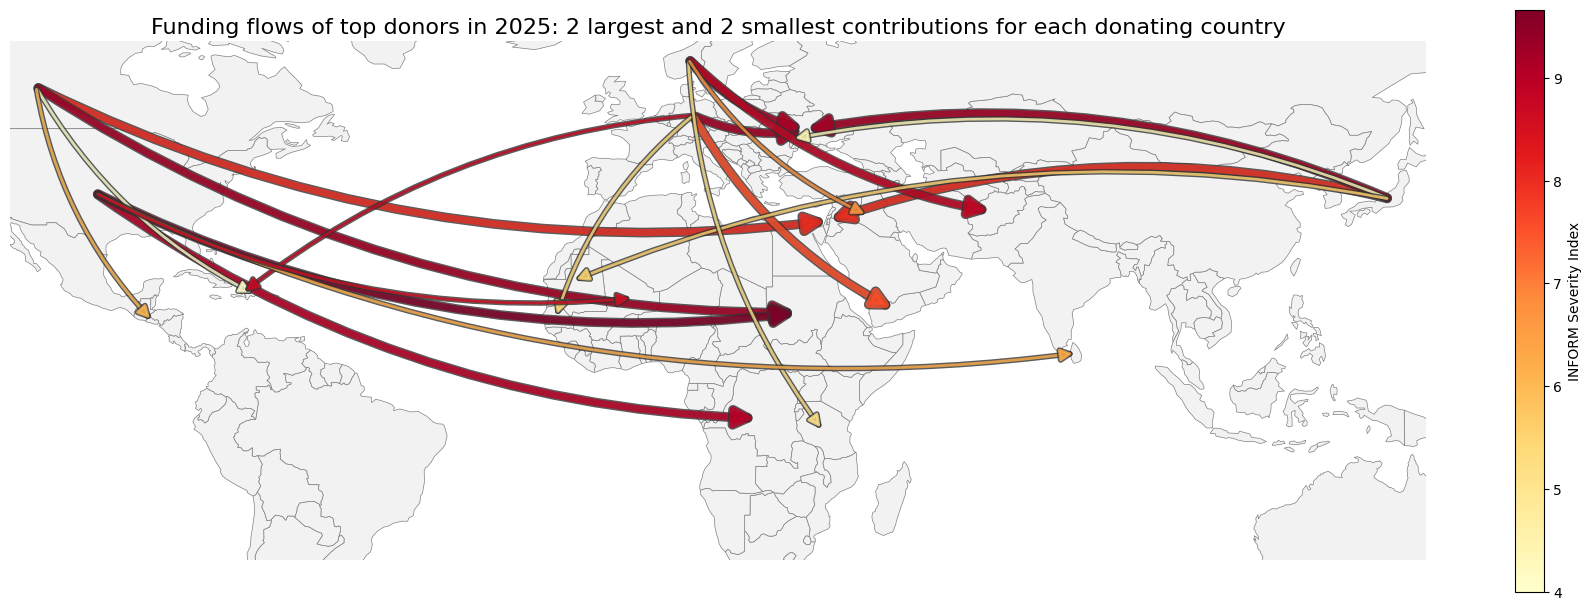

In [0]:
# --- your dataframe ---
# expected columns:
# destLocations, srcLocations, amountUSD, INFORM Severity Index
df = merged_map.copy()
df = df[df["srcLocations"].isin(top5src)]

# top = df.groupby("srcLocations", group_keys=False) \
#         .apply(lambda x: x.nlargest(2, "amountUSD"))

# bottom = df.groupby("srcLocations", group_keys=False) \
#            .apply(lambda x: x.nsmallest(2, "amountUSD"))

# df = pd.concat([top, bottom]).drop_duplicates()

top = df.groupby("srcLocations", group_keys=False) \
        .apply(lambda x: x.nlargest(2, "amountUSD")) \
        .copy()
top["width_group"] = "top"

bottom = df.groupby("srcLocations", group_keys=False) \
           .apply(lambda x: x.nsmallest(2, "amountUSD")) \
           .copy()
bottom["width_group"] = "bottom"

df = pd.concat([top, bottom]).drop_duplicates()

df["srcLocations"] = df["srcLocations"].replace({"PSE": "PSX"})
df["destLocations"] = df["destLocations"].replace({"PSE": "PSX"})

# -----------------------------
# 1) Get country coordinates
# -----------------------------
world = gpd.read_file("/Volumes/workspace/default/map/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

# naturalearth_lowres uses 'ADM0_A3'
world = world[world["ADM0_A3"] != "-99"].copy()

# representative_point is usually better than centroid for plotting labels/arrows
world["pt"] = world.geometry.representative_point()
world["lon"] = world["pt"].x
world["lat"] = world["pt"].y

coords = world[["ADM0_A3", "lon", "lat"]].copy()
coords.loc[coords["ADM0_A3"] == "NOR", ["lon", "lat"]] = [9.54, 61.77]

# source coordinates
df = df.merge(
    coords.rename(columns={
        "ADM0_A3": "srcLocations",
        "lon": "src_lon",
        "lat": "src_lat"
    }),
    on="srcLocations",
    how="left"
)

# destination coordinates
df = df.merge(
    coords.rename(columns={
        "ADM0_A3": "destLocations",
        "lon": "dest_lon",
        "lat": "dest_lat"
    }),
    on="destLocations",
    how="left"
)

# drop rows where coordinates are missing
df = df.dropna(subset=["src_lon", "src_lat", "dest_lon", "dest_lat"])

# -----------------------------
# 2) Scale color and width
# -----------------------------
severity_col = "INFORM Severity Index"
amount_col = "amountUSD"

# color: yellow -> red
norm_color = colors.Normalize(
    vmin=df[severity_col].min(),
    vmax=df[severity_col].max()
)
cmap = cm.get_cmap("YlOrRd")

# width scaling
amt_min = df[amount_col].min()
amt_max = df[amount_col].max()

def scale_width(x, min_w=1.25, max_w=5):
    if amt_min == amt_max:
        return (min_w + max_w) / 2
    return min_w + (x - amt_min) / (amt_max - amt_min) * (max_w - min_w)

# -----------------------------
# 3) Plot basemap
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 10))
world.plot(ax=ax, color="#f2f2f2", edgecolor="gray", linewidth=0.5)

# -----------------------------
# 4) Draw arrows
# -----------------------------
for _, row in df.iterrows():
    color = cmap(norm_color(row[severity_col]))
    #width = scale_width(row[amount_col])
    width = 5 if row["width_group"] == "top" else 2


    arrow = FancyArrowPatch(
        (row["src_lon"], row["src_lat"]),
        (row["dest_lon"], row["dest_lat"]),
        arrowstyle='-|>',
        mutation_scale=12 + width * 3,
        linewidth=width,
        color=color,
        alpha=0.8,
        connectionstyle="arc3,rad=0.15",
        path_effects=[
            pe.Stroke(linewidth=width + 2, foreground="#333333"),  # outline
            pe.Normal()
        ]
    )
    ax.add_patch(arrow)

# -----------------------------
# 5) Colorbar for severity
# -----------------------------
sm = cm.ScalarMappable(cmap=cmap, norm=norm_color)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label("INFORM Severity Index")

# -----------------------------
# 6) Final styling
# -----------------------------
ax.set_title("Funding flows of top donors in 2025: 2 largest and 2 smallest contributions for each donating country", fontsize=16)
ax.set_axis_off()

ax.set_xlim(-115, 145)
ax.set_ylim(-30, 65)

plt.tight_layout()
#plt.savefig("FundingFlowsMap.png", dpi=300, bbox_inches="tight")
plt.show()

In [0]:
df_table = pd.merge(df_fund, df_sev_copy, left_on=['destLocations','month-year'], right_on=['iso3','month-year'], how='inner')
df_table.head()
# df_table = df_table.dropna(subset=["destLocations"])

df_table = df_table[
    #df_table["destLocations"].isin(df_iso3["alpha-3"]) &
    df_table["srcLocations"].isin(df_iso3["alpha-3"])
]

df_table = df_table.groupby("srcLocations").apply(
    lambda x: (x["INFORM Severity Index"] * x["amountUSD"]).sum() / x["amountUSD"].sum()
).reset_index(name="weighted_severity")

df_table.sort_values("weighted_severity", ascending=False).head()

# top5sev = df_table.sort_values("weighted_severity", ascending=False).head(5)["srcLocations"]
# bot5sev = df_table.sort_values("weighted_severity", ascending=True).head(5)["srcLocations"]
# print(top5sev)
# print(bot5sev)

df_table[df_table["srcLocations"].isin(top5src)]




/home/spark-d05fd6d6-d087-4b18-a18f-48/.ipykernel/3317/command-8922628667384155-1970383149:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_table = df_table.groupby("srcLocations").apply(


,srcLocations,weighted_severity
9,CAN,7.943747
16,DEU,7.998000
34,JPN,7.229132
42,NOR,8.976825
56,USA,7.963464
